# Study 7 (Supplementary) - Hyperparameter Sensitivity and Split Robustness

Purpose: address three methodological questions a reviewer will raise about Section 2.

1. **Hyperparameter sensitivity.** The twin's constants (K, alpha, beta, sigma0, u, rho) are fixed a
   priori and are NOT tuned on the evaluation data. This notebook varies each around its default, holding
   the others fixed, and reports the onset AUROC on the Nordic network. If the conclusions are insensitive,
   the fixed values are defensible and the a-priori choice supports the label-free / transfer claims.
2. **Transition threshold rho.** rho is swept together with the other constants.
3. **Split robustness.** The interleaved even/odd-month holdout is compared against a chronological split
   and a year-blocked split, to show the twin-vs-baseline ranking is not an artefact of the split.

Task and data match the main study: Nordic PM2.5 + ERA5, 6 h steps, onset of a WHO-15 exceedance within
24 h. Nothing is executed in the repository copy; run this notebook to produce the numbers and figures.

In [1]:
import numpy as np, pandas as pd, math, matplotlib.pyplot as plt
from pathlib import Path
OUT=Path("../outputs/study7_sensitivity"); OUT.mkdir(parents=True,exist_ok=True)
plt.rcParams.update({"figure.dpi":130,"savefig.dpi":150,"font.size":11,"axes.grid":True,"grid.alpha":0.25,"axes.spines.top":False,"axes.spines.right":False})
STEP=6; H=4; TAU=15.0

pm=pd.read_csv("../data/openaq_regional/regional_pm25.csv"); pm["datetime"]=pd.to_datetime(pm["datetime"],utc=True)
pm["name"]=pm.station.str.split("::").str[1]; pm=pm.dropna(subset=["value"]); pm=pm[(pm.value>=0)&(pm.value<1500)]
met=pd.read_csv("../data/era5/era5_regional.csv",usecols=["datetime","station","wind_speed","blh","t2m"])
met["datetime"]=pd.to_datetime(met["datetime"],utc=True); met=met.rename(columns={"station":"name"})
yrs=pm.groupby("station")["datetime"].agg(lambda s:(s.max()-s.min()).days/365.25); pm=pm[pm.station.isin(yrs[yrs>=2].index)].copy()

# per-station raw 6 h series (normalisation is applied later, per split)
ST=[]
for st,g in pm.groupby("station"):
    name=g["name"].iloc[0]
    s=g.set_index("datetime").value.resample(f"{STEP}h").mean()
    mg=met[met.name==name].set_index("datetime")[["wind_speed","blh","t2m"]].resample(f"{STEP}h").mean()
    idx=s.index; A=pd.DataFrame({"pm":s}).join(mg).reindex(idx)
    ST.append(dict(idx=idx,pm=A["pm"].to_numpy(),wind=A["wind_speed"].to_numpy(),
                   blh=A["blh"].to_numpy(),temp=A["t2m"].to_numpy(),
                   month=idx.month.to_numpy(),year=idx.year.to_numpy()))
print(f"stations {len(ST)}")

stations 21


## Model and metric (parameterised)

The twin is written with every constant exposed as an argument so it can be swept. Defaults reproduce the
main study: K=5, alpha=2, beta=0.5, sigma0=1, u=0.25, rho=0.4, with downward probabilities d_lo=0.05
(elevated) and d_hi=0.15 (clean), and modality weights (PM, wind, boundary layer, temperature) =
(1.0, 0.5, 0.5, 0.4). Meteorological signals are inverted so that larger values indicate greater hazard.

In [2]:
def twin(zpm,zw,zb,zt,K=5,alpha=2.0,beta=0.5,sigma0=1.0,u=0.25,rho=0.4,dlo=0.05,dhi=0.15,w=(1.0,0.5,0.5,0.4)):
    lev=[i/(K-1) for i in range(K)]; sd=[sigma0+beta*l for l in lev]
    lgc=[-0.5*math.log(2*math.pi)-math.log(s) for s in sd]
    def lgv(z): return [lgc[k]-0.5*((z-alpha*lev[k])/sd[k])**2 for k in range(K)]
    logb=[-3*k for k in range(K)]; m=max(logb); ss=sum(math.exp(x-m) for x in logb); logb=[x-m-math.log(ss) for x in logb]
    n=len(zpm); risk=np.empty(n)
    for t in range(n):
        mb=max(logb); b=[math.exp(x-mb) for x in logb]; sb=sum(b); b=[x/sb for x in b]
        el=sum(b[k]*lev[k] for k in range(K)); dd=dlo if el>rho else dhi; bp=[0.0]*K
        for k in range(K):
            uk=u if k<K-1 else 0.0; dk=dd if k>0 else 0.0; bp[k]+=b[k]*(1-uk-dk)
            if k<K-1: bp[k+1]+=b[k]*uk
            if k>0: bp[k-1]+=b[k]*dk
        logbp=[math.log(x+1e-12) for x in bp]
        for zv,ww,inv in [(zpm,w[0],1),(zw,w[1],-1),(zb,w[2],-1),(zt,w[3],-1)]:
            z=zv[t]
            if not math.isnan(z):
                lv=lgv(inv*z); logbp=[logbp[k]+ww*lv[k] for k in range(K)]
        m2=max(logbp); s2=math.log(sum(math.exp(x-m2) for x in logbp)); logb=[x-m2-s2 for x in logbp]
        eb=[math.exp(x) for x in logb]; risk[t]=sum(eb[k]*lev[k] for k in range(K))
    return risk

def auc(s,y):
    s=np.asarray(s,float);y=np.asarray(y,int);pos,neg=(y==1),(y==0)
    if pos.sum()==0 or neg.sum()==0:return np.nan
    o=np.argsort(s);r=np.empty(len(s));r[o]=np.arange(1,len(s)+1)
    u,inv,c=np.unique(s,return_inverse=True,return_counts=True);sm=np.zeros(len(c));np.add.at(sm,inv,r);r=(sm/c)[inv]
    return float((r[pos].sum()-pos.sum()*(pos.sum()+1)/2)/(pos.sum()*neg.sum()))

def zscore(v,train_mask,log=False):
    x=np.log1p(np.clip(v,0,None)) if log else v
    mu,sd=np.nanmean(x[train_mask]),np.nanstd(x[train_mask])+1e-9
    return (x-mu)/sd

def evaluate(train_of, params=None):
    '''train_of(d)->bool array marking training timesteps for station d.
       Returns test-set twin AUROC and current-level baseline AUROC.'''
    params=params or {}
    sc_tw=[]; sc_cur=[]; yy=[]
    for d in ST:
        tm=train_of(d)
        zpm=zscore(d["pm"],tm,log=True); zw=zscore(d["wind"],tm); zb=zscore(d["blh"],tm); zt=zscore(d["temp"],tm)
        risk=twin(zpm,zw,zb,zt,**params); v=d["pm"]
        for t in range(2,len(v)-H):
            if np.isnan(v[t]) or v[t]>=TAU or tm[t]: continue   # test timesteps only
            fut=v[t+1:t+1+H]
            if np.all(np.isnan(fut)): continue
            yy.append(int(np.nanmax(fut)>=TAU)); sc_tw.append(risk[t]); sc_cur.append(zpm[t] if not np.isnan(zpm[t]) else 0.0)
    return auc(sc_tw,yy), auc(sc_cur,yy)

interleaved=lambda d: (d["month"]%2==0)   # default split used in the main study

## 1. Hyperparameter sweep (interleaved split)

Each parameter is varied around its default with the others fixed. A robust framework shows a flat or
gently varying onset AUROC across reasonable values, and a twin score that stays at or above the
current-level baseline throughout.

K      : 3=0.794  4=0.794  5=0.794  6=0.793  7=0.792
alpha  : 1.5=0.793  2.0=0.794  2.5=0.793  3.0=0.791
beta   : 0.0=0.783  0.25=0.789  0.5=0.794  0.75=0.794  1.0=0.786
sigma0 : 0.75=0.795  1.0=0.794  1.25=0.792  1.5=0.789
u      : 0.15=0.794  0.2=0.794  0.25=0.794  0.3=0.794  0.35=0.794
rho    : 0.3=0.793  0.4=0.794  0.5=0.794  0.6=0.794

current-level baseline AUROC (reference): 0.759


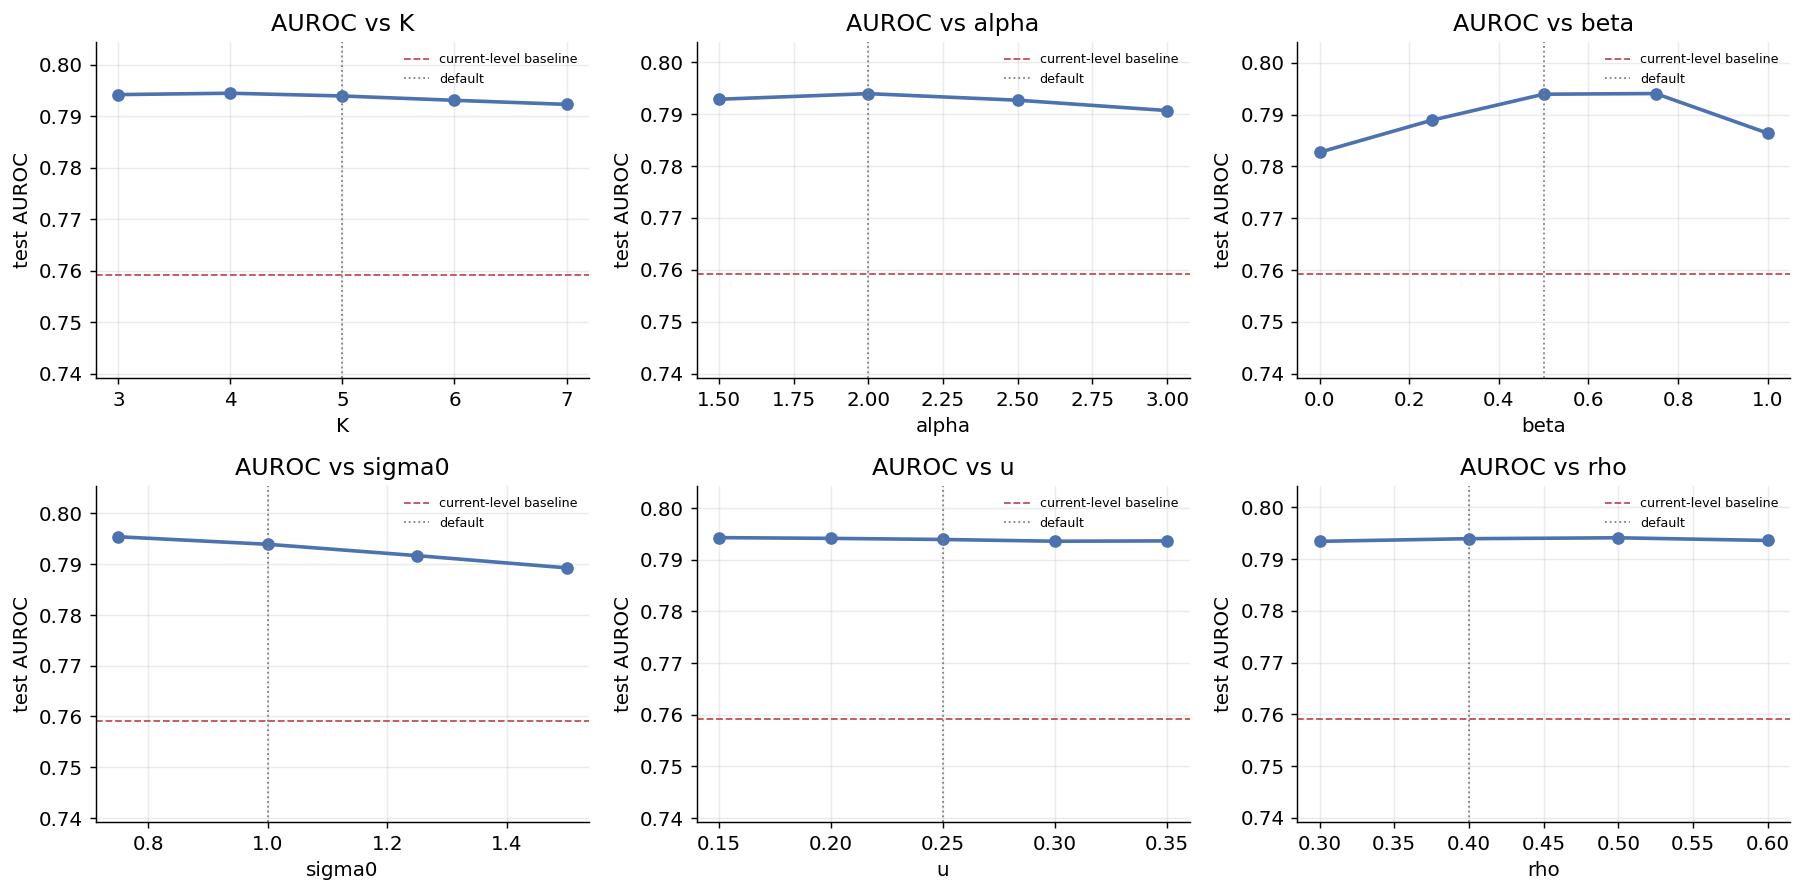

largest AUROC span across any single-parameter sweep: 0.011


In [3]:
GRID={
 "K":[3,4,5,6,7],
 "alpha":[1.5,2.0,2.5,3.0],
 "beta":[0.0,0.25,0.5,0.75,1.0],
 "sigma0":[0.75,1.0,1.25,1.5],
 "u":[0.15,0.20,0.25,0.30,0.35],
 "rho":[0.3,0.4,0.5,0.6],
}
DEFAULT={"K":5,"alpha":2.0,"beta":0.5,"sigma0":1.0,"u":0.25,"rho":0.4}
base_cur=None; results={}
for pname,vals in GRID.items():
    aucs=[]
    for val in vals:
        params=dict(DEFAULT); params[pname]=val
        a_tw,a_cur=evaluate(interleaved,params); aucs.append(a_tw)
        if base_cur is None: base_cur=a_cur
    results[pname]=(vals,aucs)
    print(f"{pname:7s}: "+"  ".join(f"{v}={a:.3f}" for v,a in zip(vals,aucs)))
print(f"\ncurrent-level baseline AUROC (reference): {base_cur:.3f}")

fig,ax=plt.subplots(2,3,figsize=(14,7))
for a,(pname,(vals,aucs)) in zip(ax.ravel(),results.items()):
    a.plot(vals,aucs,"-o",color="#4C72B0",lw=2)
    a.axhline(base_cur,ls="--",c="#C44E52",lw=1,label="current-level baseline")
    a.axvline(DEFAULT[pname],ls=":",c="grey",lw=1,label="default")
    a.set_title(f"AUROC vs {pname}"); a.set_xlabel(pname); a.set_ylabel("test AUROC")
    a.set_ylim(min(base_cur-0.02,min(aucs)-0.01), max(aucs)+0.01); a.legend(fontsize=7,frameon=False)
plt.tight_layout(); plt.savefig(OUT/"fig1_hyperparam_sensitivity.png",bbox_inches="tight"); plt.show()
span=max(max(a)-min(a) for _,a in results.values())
print(f"largest AUROC span across any single-parameter sweep: {span:.3f}")

## 2. Split robustness

The interleaved even/odd-month holdout matches the seasonal distribution between train and test, but a
reviewer may prefer a chronological or blocked split. The twin and the current-level baseline are
evaluated under three schemes. Stable AUROC and a stable ranking indicate the conclusions are not an
artefact of the interleaving.

                     twin_AUROC  current_level_AUROC  twin_minus_baseline
split                                                                    
interleaved months        0.794                0.759                0.035
chronological 70/30       0.815                0.770                0.044
year-blocked              0.765                0.744                0.021


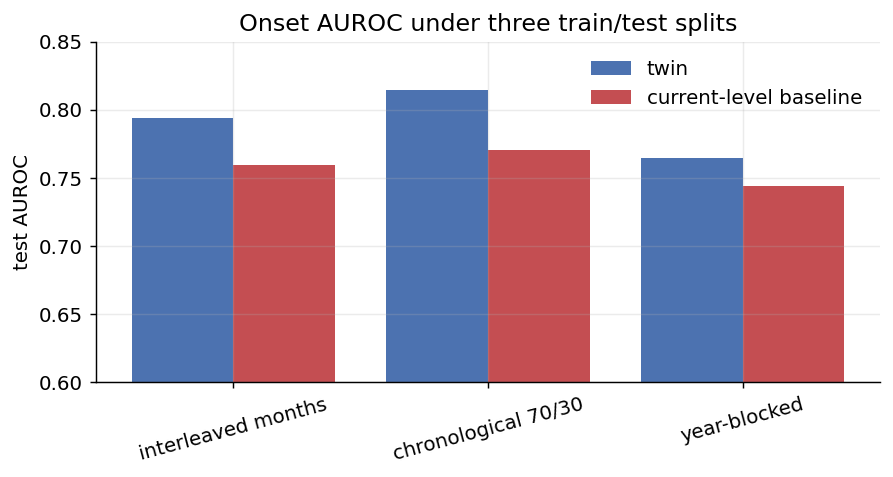

In [4]:
def chronological(d):
    # first 70% of the station timeline is training
    n=len(d["pm"]); cut=int(0.7*n); m=np.zeros(n,bool); m[:cut]=True; return m
def year_blocked(d):
    # odd years train, even years test
    return (d["year"]%2==1)

schemes={"interleaved months":interleaved,"chronological 70/30":chronological,"year-blocked":year_blocked}
rows=[]
for nm,fn in schemes.items():
    a_tw,a_cur=evaluate(fn,DEFAULT); rows.append((nm,a_tw,a_cur,a_tw-a_cur))
tab=pd.DataFrame(rows,columns=["split","twin_AUROC","current_level_AUROC","twin_minus_baseline"]).set_index("split")
print(tab.round(3).to_string())

fig,ax=plt.subplots(figsize=(7,3.8)); x=np.arange(len(tab))
ax.bar(x-0.2,tab.twin_AUROC,0.4,label="twin",color="#4C72B0")
ax.bar(x+0.2,tab.current_level_AUROC,0.4,label="current-level baseline",color="#C44E52")
ax.set_xticks(x); ax.set_xticklabels(tab.index,rotation=15); ax.set_ylabel("test AUROC")
ax.set_ylim(0.6,0.85); ax.set_title("Onset AUROC under three train/test splits"); ax.legend(frameon=False)
plt.tight_layout(); plt.savefig(OUT/"fig2_split_robustness.png",bbox_inches="tight"); plt.show()